In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


🎯 Preparing to train WINNING STAGE 2 MODEL:
   • Learning Rate : 2.5e-05
   • LR Scheduler  : cosine
   • Save Target   : /content/drive/MyDrive/Workshop/Stage_2/models/stage2_dictabert/


config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: reconstructing file:   0%|          |  0.00B / 1.50MB            

vocab.txt: downloading bytes:           |  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


📊 Training Complete. Running final diagnostic evaluation...

🏆 FINAL STAGE 2 WINNING MODEL PERFORMANCE
  • Token Exact Match (EM) : 76.71%
  • Token F1-Score        : 80.97%
  • Text Exact Match (EM)  : 69.67%
  • Text F1-Score         : 73.44%
  • Macro F1-Score        : 0.3621
  • Weighted F1-Score     : 0.6871
  • Explicit Span Accuracy: 69.67%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


💾 Model weights & tokenizer successfully exported to:
   /content/drive/MyDrive/Workshop/Stage_2/models/stage2_dictabert/


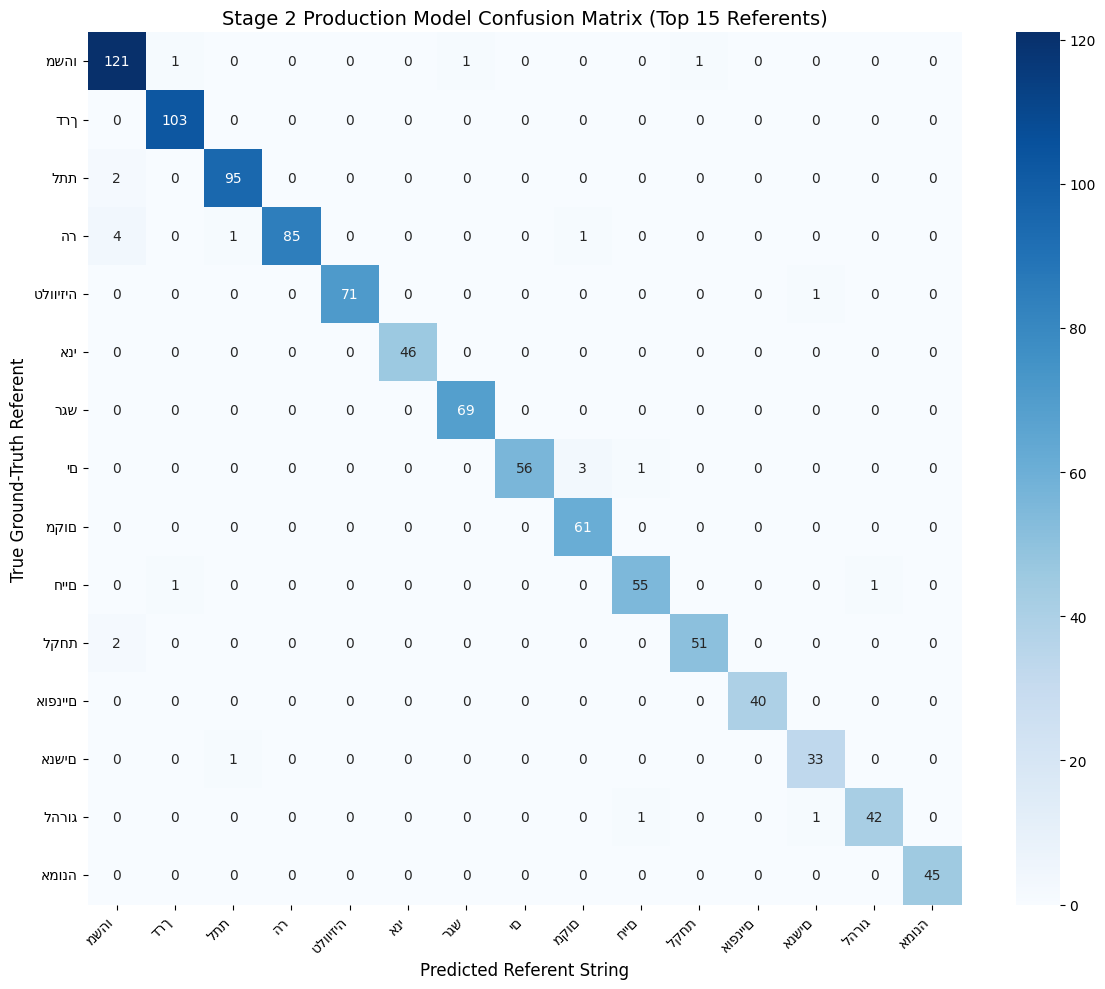

In [ ]:
# ==============================================================================
# STAGE 2 DICTABERT
# ==============================================================================
import os
import re
import inspect
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    Trainer,
    TrainingArguments,
)

# ------------------------------------------------------------------------------
# CONFIGURATION & PATHS
# ------------------------------------------------------------------------------
MODEL_NAME = "dicta-il/dictabert"
DRIVE_BEST_PATH = "/content/drive/MyDrive/Workshop/Stage_2/models/stage2_dictabert/"
OUTPUT_TMP_DIR = "/tmp/stage2_winning_run"

TRAIN_PATH = "train_set.csv" if os.path.exists("train_set.csv") else "stage2_prompt_span_splits/train_set.csv"
VAL_PATH = "val_set.csv" if os.path.exists("val_set.csv") else "stage2_prompt_span_splits/val_set.csv"

WINNING_CONFIG = {"lr": 2.5e-5, "scheduler": "cosine"}

print(f"🎯 Preparing to train WINNING STAGE 2 MODEL:")
print(f"   • Learning Rate : {WINNING_CONFIG['lr']}")
print(f"   • LR Scheduler  : {WINNING_CONFIG['scheduler']}")
print(f"   • Save Target   : {DRIVE_BEST_PATH}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
SPECIAL_TOKENS = {"additional_special_tokens": ["<mv>", "</mv>"]}
tokenizer.add_special_tokens(SPECIAL_TOKENS)

# ------------------------------------------------------------------------------
# DATASET & HELPERS
# ------------------------------------------------------------------------------
class Stage2QADataset(Dataset):
    def __init__(self, csv_path, tokenizer, max_len=160, is_train=True):
        self.df = pd.read_csv(csv_path).dropna(
            subset=["Full_Raw_Sentence", "MeaningVal", "Referent"]
        )
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt_word = str(row.get("Prompt_Word", row["MeaningVal"])).strip()
        sentence = str(row["Full_Raw_Sentence"]).strip()
        meaning_val = str(row["MeaningVal"]).strip()
        referent = str(row["Referent"]).strip()

        marked_sentence = sentence.replace(meaning_val, f"<mv> {meaning_val} </mv>", 1) if meaning_val in sentence else sentence
        context = f"גירוי: {prompt_word} | משפט: {marked_sentence}"
        question = f"מהו הרפרנט של יחידת המשמעות: {meaning_val} ?"

        encoding = self.tokenizer(
            question,
            context,
            max_length=self.max_len,
            padding="max_length",
            truncation="only_second",
            return_offsets_mapping=True,
            return_token_type_ids=True,
            return_tensors="pt",
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        token_type_ids = encoding["token_type_ids"].squeeze(0)

        ref_start_char = context.find(referent)
        ref_len = len(referent) if ref_start_char != -1 else len(prompt_word)
        if ref_start_char == -1:
            ref_start_char = context.find(prompt_word)

        if ref_start_char == -1:
            start_tok_idx, end_tok_idx = 0, 0
        else:
            ref_end_char = ref_start_char + ref_len - 1
            start_tok = encoding.char_to_token(0, ref_start_char, sequence_index=1)
            end_tok = encoding.char_to_token(0, ref_end_char, sequence_index=1)
            start_tok_idx = start_tok if start_tok is not None else 0
            end_tok_idx = end_tok if end_tok is not None else 0

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "start_positions": torch.tensor(start_tok_idx, dtype=torch.long),
            "end_positions": torch.tensor(end_tok_idx, dtype=torch.long),
            "raw_referent": referent,
            "raw_context": context,
        }

def normalize_hebrew_text(text):
    text = re.sub(r"[^\w\s]", "", text)
    return " ".join(text.strip().split())

def extract_best_valid_span_fast(start_logits, end_logits, token_type_ids, max_span_len=12):
    seq_len = len(start_logits)
    context_mask = (token_type_ids == 1)
    score_matrix = start_logits[:, None] + end_logits[None, :]
    indices = np.arange(seq_len)
    i_idx, j_idx = np.meshgrid(indices, indices, indexing='ij')

    valid_mask = (
        (i_idx <= j_idx) &
        ((j_idx - i_idx + 1) <= max_span_len) &
        context_mask[:, None] &
        context_mask[None, :]
    )

    score_matrix[~valid_mask] = -1e9
    best_idx = np.unravel_index(np.argmax(score_matrix), score_matrix.shape)
    return best_idx[0], best_idx[1]

def run_full_diagnostics(model, val_loader, device, tokenizer):
    model.eval()
    token_em_list, token_f1_list = [], []
    text_em_list, text_f1_list = [], []
    pred_texts, gold_texts = [], []
    explicit_em, explicit_count = 0, 0
    implicit_em, implicit_count = 0, 0

    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        gold_starts = batch["start_positions"].numpy()
        gold_ends = batch["end_positions"].numpy()
        gold_raw_texts = batch["raw_referent"]

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )
            batch_start_logits = outputs.start_logits.cpu().numpy()
            batch_end_logits = outputs.end_logits.cpu().numpy()
            batch_types = token_type_ids.cpu().numpy()

        for i in range(len(gold_starts)):
            p_start, p_end = extract_best_valid_span_fast(
                batch_start_logits[i], batch_end_logits[i], batch_types[i]
            )
            g_start, g_end = gold_starts[i], gold_ends[i]

            tok_em = 1.0 if (p_start == g_start and p_end == g_end) else 0.0
            token_em_list.append(tok_em)

            p_tokens = input_ids[i][p_start : p_end + 1].cpu().tolist() if p_start <= p_end else []
            g_tokens = input_ids[i][g_start : g_end + 1].cpu().tolist() if g_start <= g_end else []

            p_counter, g_counter = Counter(p_tokens), Counter(g_tokens)
            num_same = sum((p_counter & g_counter).values())

            if len(p_tokens) == 0 or len(g_tokens) == 0:
                tok_f1 = 1.0 if p_tokens == g_tokens else 0.0
            elif num_same == 0:
                tok_f1 = 0.0
            else:
                prec = num_same / len(p_tokens)
                rec = num_same / len(g_tokens)
                tok_f1 = 2 * (prec * rec) / (prec + rec)
            token_f1_list.append(tok_f1)

            pred_raw = tokenizer.decode(p_tokens, skip_special_tokens=True)
            pred_clean = normalize_hebrew_text(re.sub(r"</?mv>", "", pred_raw))
            gold_clean = normalize_hebrew_text(gold_raw_texts[i])

            pred_texts.append(pred_clean)
            gold_texts.append(gold_clean)

            txt_em = 1.0 if pred_clean == gold_clean else 0.0
            text_em_list.append(txt_em)

            p_words, g_words = pred_clean.split(), gold_clean.split()
            common_words = sum((Counter(p_words) & Counter(g_words)).values())
            if not p_words or not g_words:
                txt_f1 = 1.0 if pred_clean == gold_clean else 0.0
            elif common_words == 0:
                txt_f1 = 0.0
            else:
                prec = common_words / len(p_words)
                rec = common_words / len(g_words)
                txt_f1 = 2 * (prec * rec) / (prec + rec)
            text_f1_list.append(txt_f1)

            if g_start <= 5:
                implicit_count += 1
                if txt_em == 1.0: implicit_em += 1
            else:
                explicit_count += 1
                if txt_em == 1.0: explicit_em += 1

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(gold_texts, pred_texts, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(gold_texts, pred_texts, average="weighted", zero_division=0)

    explicit_acc = (explicit_em / explicit_count * 100) if explicit_count > 0 else 0.0
    implicit_acc = (implicit_em / implicit_count * 100) if implicit_count > 0 else 0.0

    return {
        "token_em": np.mean(token_em_list) * 100,
        "token_f1": np.mean(token_f1_list) * 100,
        "text_em": np.mean(text_em_list) * 100,
        "text_f1": np.mean(text_f1_list) * 100,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "explicit_acc": explicit_acc,
        "implicit_acc": implicit_acc,
        "gold_texts": gold_texts,
        "pred_texts": pred_texts,
    }

# ------------------------------------------------------------------------------
# SINGLE-RUN EXECUTION
# ------------------------------------------------------------------------------
train_dataset = Stage2QADataset(TRAIN_PATH, tokenizer, is_train=True)
val_dataset = Stage2QADataset(VAL_PATH, tokenizer, is_train=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size, num_epochs = 16, 3
total_steps = (len(train_dataset) // batch_size) * num_epochs
warmup_steps = int(0.10 * total_steps)

ta_params = inspect.signature(TrainingArguments.__init__).parameters
eval_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

print(f"\n🚀 Starting Training Run...")
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))

training_args = TrainingArguments(**{
    eval_key: "epoch",
    "output_dir": OUTPUT_TMP_DIR,
    "save_strategy": "epoch",
    "learning_rate": WINNING_CONFIG["lr"],
    "lr_scheduler_type": WINNING_CONFIG["scheduler"],
    "per_device_train_batch_size": batch_size,
    "per_device_eval_batch_size": batch_size,
    "num_train_epochs": num_epochs,
    "warmup_steps": warmup_steps,
    "weight_decay": 0.01,
    "logging_steps": 50,
    "save_total_limit": 1,
    "save_only_model": True,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
})

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

# ------------------------------------------------------------------------------
# DIAGNOSTICS & EXPORT TO GOOGLE DRIVE
# ------------------------------------------------------------------------------
print("\n📊 Training Complete. Running final diagnostic evaluation...")
model.to(device)
diag = run_full_diagnostics(model, val_loader, device, tokenizer)

print("\n" + "=" * 65)
print("🏆 FINAL STAGE 2 WINNING MODEL PERFORMANCE")
print("=" * 65)
print(f"  • Token Exact Match (EM) : {diag['token_em']:.2f}%")
print(f"  • Token F1-Score        : {diag['token_f1']:.2f}%")
print(f"  • Text Exact Match (EM)  : {diag['text_em']:.2f}%")
print(f"  • Text F1-Score         : {diag['text_f1']:.2f}%")
print(f"  • Macro F1-Score        : {diag['macro_f1']:.4f}")
print(f"  • Weighted F1-Score     : {diag['weighted_f1']:.4f}")
print(f"  • Explicit Span Accuracy: {diag['explicit_acc']:.2f}%")
print("=" * 65)

os.makedirs(DRIVE_BEST_PATH, exist_ok=True)
model.save_pretrained(DRIVE_BEST_PATH)
tokenizer.save_pretrained(DRIVE_BEST_PATH)
print(f"\n💾 Model weights & tokenizer successfully exported to:\n   {DRIVE_BEST_PATH}")

# ------------------------------------------------------------------------------
# CONFUSION MATRIX PLOT
# ------------------------------------------------------------------------------
gold_texts = diag["gold_texts"]
pred_texts = diag["pred_texts"]
gold_counts = Counter(gold_texts)

TOP_N = 15
top_classes = [item[0] for item in gold_counts.most_common(TOP_N)]
mask = [g in top_classes and p in top_classes for g, p in zip(gold_texts, pred_texts)]
filtered_gold = [g for g, m in zip(gold_texts, mask) if m]
filtered_pred = [p for p, m in zip(pred_texts, mask) if m]

cm = confusion_matrix(filtered_gold, filtered_pred, labels=top_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=top_classes, yticklabels=top_classes)
plt.title(f"Stage 2 Production Model Confusion Matrix (Top {TOP_N} Referents)", fontsize=14)
plt.xlabel("Predicted Referent String", fontsize=12)
plt.ylabel("True Ground-Truth Referent", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()